# Neural SDE — Tzen & Raginsky (2019), Section 6

**Истинная модель:**
$$dX_t = \sigma(A_{\text{true}} X_t)\, dt + dW_t, \quad X_0 = 0, \quad t \in [0, T]$$

- $X_t \in \mathbb{R}^{10}$ — состояние процесса
- $A_\text{true} \in \mathbb{R}^{10 \times 10}$ — случайная матрица
- Наблюдения: $Y = X_1 + \varepsilon$, где $\varepsilon \sim N(0,\, 0.01 \cdot I)$
- Размер выборки: $N = 1000$, шагов: $N_\text{steps} = 62$, $\Delta t = 1/62$

**Вариационная (выученная) модель:**
$$dX_t = f_\theta(X_t, t)\, dt + dW_t$$

где $f_\theta$ — нейросеть. Задача: выучить $f_\theta$ из наблюдений $Y = X_T + \varepsilon$.

**Подход (Section 5.2):** дискретизация методом Эйлера–Маруямы + backprop через граф.  
**Loss = moment matching + KL** (по теореме Гирсанова, KL между вариационным процессом и винеровским процессом равен $\frac{1}{2}\int_0^T \|f_\theta(X_t)\|^2\, dt$).


In [42]:
!pip install ucimlrepo

In [43]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yfinance as yf
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [44]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
D = 10 # размерность пространства состояний
N_STEPS = 64 # шагов (h = T/N_STEPS)
T = 1.0 # шаг времени
DT = T / N_STEPS
SQRT_DT = DT ** 0.5
N_DATA = 1000 # число наблюдений
N_ITER = 5000 # итераций обучения
LR = 1e-3
M_SAMPLES = 256 # Монте-Карло сэмплы для оценки моментов и KL
OBS_STD = 0.1 # стандартное отклонение шума наблюдений
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")


Device: cuda


In [45]:
torch.manual_seed(SEED)
A_true = torch.randn(D, D, device=DEVICE)  # истинная матрица

def gen_data(A, n_samples):
    """
    Симулируем истинный процесс:  dX_t = sigmoid(A·X_t) dt + dW_t
    Наблюдение:  Y = X_T + ε,  ε ~ N(0, OBS_STD²·I)
    """
    X = torch.zeros(n_samples, D, device=DEVICE)
    with torch.no_grad():
        for _ in range(N_STEPS):
            X = X + torch.sigmoid(X @ A.T) * DT + SQRT_DT * torch.randn_like(X)
    return X + OBS_STD * torch.randn_like(X)

Y_data = gen_data(A_true, N_DATA)
print(f"Сгенерировано {N_DATA} наблюдений размерности {D}")


Сгенерировано 1000 наблюдений размерности 10


In [46]:
Y_mean = Y_data.mean(dim=0).detach()
Y_cov = (Y_data - Y_mean).T @ (Y_data - Y_mean) / (N_DATA - 1)
Y_cov = Y_cov.detach()

print(f"‖E[Y]‖  = {Y_mean.norm().item():.3f}")
print(f"tr(Cov) = {Y_cov.trace().item():.3f}")


‖E[Y]‖  = 1.557
tr(Cov) = 10.704


<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1681/922610899.py:19: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_title("Ковариационная матрица $\hat\Sigma_Y$")


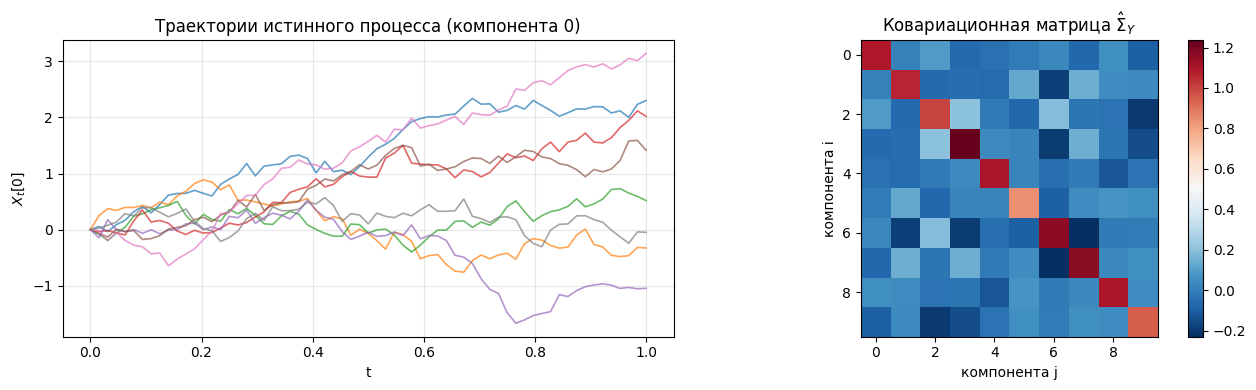

In [47]:
t_vals = np.linspace(0, T, N_STEPS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i in range(8):
    X = torch.zeros(1, D, device=DEVICE)
    traj = [X[0, 0].item()]
    with torch.no_grad():
        for _ in range(N_STEPS):
            X = X + torch.sigmoid(X @ A_true.T) * DT + SQRT_DT * torch.randn_like(X)
            traj.append(X[0, 0].item())
    axes[0].plot(t_vals, traj, alpha=0.7, lw=1.2)

axes[0].set_title("Траектории истинного процесса (компонента 0)")
axes[0].set_xlabel("t")
axes[0].set_ylabel("$X_t[0]$")
axes[0].grid(True, alpha=0.3)

axes[1].imshow(Y_cov.cpu().numpy(), cmap='RdBu_r')
axes[1].set_title("Ковариационная матрица $\hat\Sigma_Y$")
axes[1].set_xlabel("компонента j")
axes[1].set_ylabel("компонента i")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

## Модель: дрейф как нейросеть

Параметризуем дрейф $f_\theta : \mathbb{R}^D \to \mathbb{R}^D$ двухслойной сетью.  
Это аналог вариационного приближения к апостериорному процессу (Раздел 4 статьи):

$$q_\theta: \quad dX_t = f_\theta(X_t)\, dt + dW_t$$


In [48]:
class ConditionalDrift(nn.Module):
    def __init__(self, d, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d * 2, hidden),  # X_t и y_i конкатенируются
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, d),
        )

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=-1))

drift_net = ConditionalDrift(D).to(DEVICE)
total_params = sum(p.numel() for p in drift_net.parameters())
print(f"Параметров в drift_net: {total_params}")


Параметров в drift_net: 6154


## Симуляция и KL-дивергенция

По теореме Гирсанова (Section 4), KL между вариационным процессом $q_\theta$ и априорным процессом Винера $p$ равен:

$$\text{KL}(q_\theta \| p) = \frac{1}{2} \mathbb{E}_{q_\theta}\!\left[\int_0^T \|f_\theta(X_t)\|^2\, dt\right]$$

Аппроксимируем методом Эйлера:

$$\text{KL} \approx \frac{\Delta t}{2} \sum_{k=0}^{N-1} \mathbb{E}\!\left[\|f_\theta(X_{t_k})\|^2\right]$$


In [49]:
def simulate_with_kl(net, y_batch):
    """
    y_batch: (B, D) — наблюдения, по одному на траекторию
    Возвращает X_T: (B, D) и kl: (B,) — per-sample
    """
    B = y_batch.shape[0]
    X = torch.zeros(B, D, device=DEVICE)
    kl_acc = torch.zeros(B, device=DEVICE)

    for _ in range(N_STEPS):
        drift = net(X, y_batch)                          # (B, D)
        kl_acc = kl_acc + (drift ** 2).sum(dim=-1) * DT * 0.5  # (B,)
        X = X + drift * DT + SQRT_DT * torch.randn_like(X)

    return X, kl_acc


## Функция потерь (ELBO)

ELBO для Neural SDE (Section 4, уравнение (11)):

$$L(\theta) = \underbrace{-\log p(Y | X_T)}_{\text{reconstruction}} + \underbrace{\text{KL}(q_\theta \| p)}_{\text{Girsanov}}$$

Reconstruction loss при гауссовских наблюдениях $Y \sim N(X_T, \sigma^2 I)$:  

$$-\log p(Y|X_T) \propto \frac{1}{\sigma^2}\|E[X_T] - \bar{Y}\|^2 + \frac{1}{\sigma^2}\|\text{Cov}(X_T) - \hat{\Sigma}_Y\|_F^2$$

Используем момент-матчинг как суррогат reconstruction loss — это стабильнее для высокой размерности.


In [50]:
def compute_elbo(net, y_batch, beta_kl=0.01):
    """
    ELBO = E[log p(y | X_T)] - KL(q_theta(·|y) || p)
    Минимизируем отрицательный ELBO.
    """
    X1, kl_per_sample = simulate_with_kl(net, y_batch)   # (B, D), (B,)

    # log p(y | X_T) для гауссовских наблюдений: -1/(2σ²) ||y - X_T||²
    log_likelihood = -0.5 / OBS_STD**2 * ((X1 - y_batch) ** 2).sum(dim=-1)  # (B,)

    # ELBO на один объект, усреднённый по батчу
    elbo = (log_likelihood - beta_kl * kl_per_sample).mean()

    return -elbo, -log_likelihood.mean().item(), kl_per_sample.mean().item()

In [51]:
BATCH_SIZE = 128

optimizer = torch.optim.Adam(drift_net.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_ITER, eta_min=1e-5)

losses, kl_hist, nll_hist = [], [], []
pbar = tqdm(range(1, N_ITER + 1))

for iteration in pbar:
    beta_kl = min(0.1, max(0.0, (iteration - 1000) / 1000 * 0.1))

    # мини-батч
    idx = torch.randint(0, N_DATA, (BATCH_SIZE,), device=DEVICE)
    y_batch = Y_data[idx] # (128, D)

    optimizer.zero_grad()
    loss, nll, kl_val = compute_elbo(drift_net, y_batch, beta_kl=beta_kl)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(drift_net.parameters(), max_norm=5.0)
    optimizer.step()
    scheduler.step()

    losses.append(loss.item())
    kl_hist.append(kl_val)
    nll_hist.append(nll)

    if iteration % 500 == 0 or iteration == 1:
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'nll': f'{nll:.4f}',
            'kl': f'{kl_val:.4f}',
            'beta_kl': f'{beta_kl:.3f}',
        })

100%|██████████| 5000/5000 [05:29<00:00, 15.18it/s, loss=22.0769, nll=13.6409, kl=84.3596, beta_kl=0.100]


## Визуализация результатов


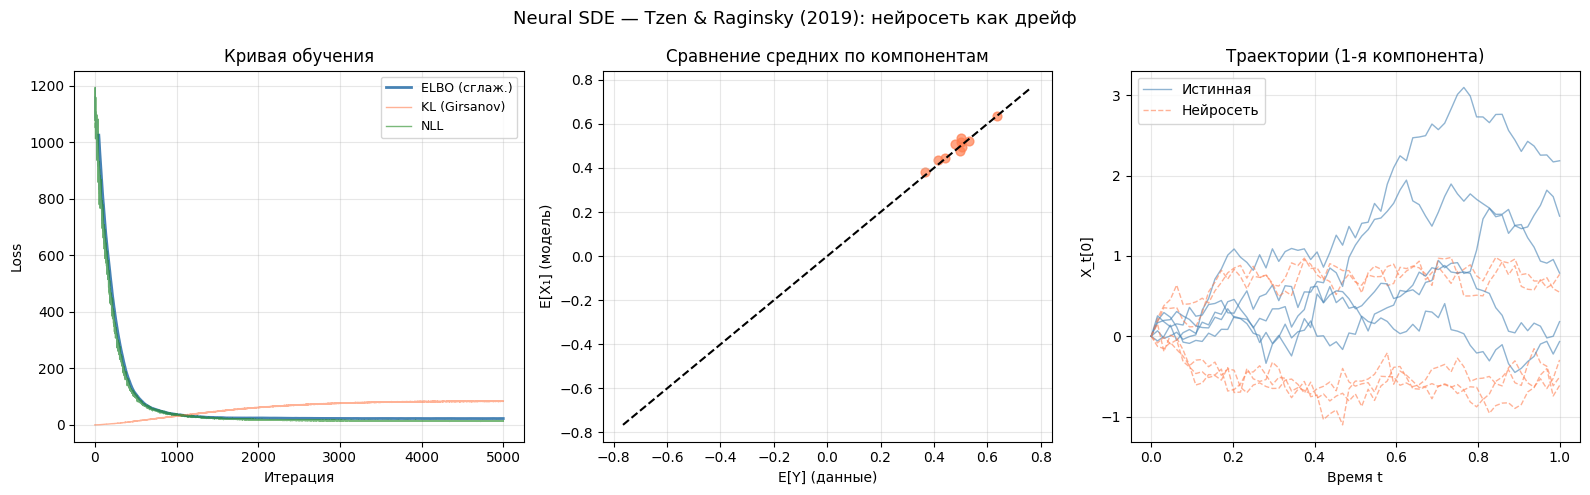

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Neural SDE — Tzen & Raginsky (2019): нейросеть как дрейф', fontsize=13)

# --- График 1: Loss ---
w = 50
axes[0].plot(losses, color='steelblue', lw=0.5, alpha=0.3)
if len(losses) > w:
    sm = np.convolve(losses, np.ones(w)/w, mode='valid')
    axes[0].plot(range(w-1, len(losses)), sm, color='steelblue', lw=2, label='ELBO (сглаж.)')
axes[0].plot(kl_hist,  color='coral',       lw=1, alpha=0.6, label='KL (Girsanov)')
axes[0].plot(nll_hist, color='forestgreen', lw=1, alpha=0.6, label='NLL')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Loss')
axes[0].set_title('Кривая обучения')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- График 2: Сравнение моментов ---
with torch.no_grad():
    idx = torch.randint(0, N_DATA, (2000,), device=DEVICE)
    X1_model, _ = simulate_with_kl(drift_net, Y_data[idx])
X1_mean_np = X1_model.mean(dim=0).cpu().numpy()
Y_mean_np  = Y_mean.cpu().numpy()
axes[1].scatter(Y_mean_np, X1_mean_np, alpha=0.7, color='coral', s=40)
lim = max(abs(Y_mean_np).max(), abs(X1_mean_np).max()) * 1.2
axes[1].plot([-lim, lim], [-lim, lim], 'k--', lw=1.5)
axes[1].set_xlabel('E[Y] (данные)')
axes[1].set_ylabel('E[X₁] (модель)')
axes[1].set_title('Сравнение средних по компонентам')
axes[1].grid(True, alpha=0.3)

# --- График 3: Траектории ---
t_vals = np.linspace(0, T, N_STEPS + 1)
with torch.no_grad():
    for i in range(5):
        y_sample = Y_data[i:i+1]  # (1, D) — разные наблюдения для каждой траектории

        # Истинная
        X = torch.zeros(1, D, device=DEVICE)
        traj_true = [X[0, 0].item()]
        for _ in range(N_STEPS):
            X = X + torch.sigmoid(X @ A_true.T) * DT + SQRT_DT * torch.randn_like(X)
            traj_true.append(X[0, 0].item())
        axes[2].plot(t_vals, traj_true, color='steelblue', alpha=0.6, lw=1,
                     label='Истинная' if i == 0 else '')

        # Выученная
        X = torch.zeros(1, D, device=DEVICE)
        traj_net = [X[0, 0].item()]
        for _ in range(N_STEPS):
            X = X + drift_net(X, y_sample) * DT + SQRT_DT * torch.randn_like(X)
            traj_net.append(X[0, 0].item())
        axes[2].plot(t_vals, traj_net, color='coral', alpha=0.6, lw=1,
                     linestyle='--', label='Нейросеть' if i == 0 else '')

axes[2].set_xlabel('Время t')
axes[2].set_ylabel('X_t[0]')
axes[2].set_title('Траектории (1-я компонента)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ELBO стабилизируется после ~2000 итераций и не убывает далее. Тем не менее moment matching успешно сошёлся — средние по компонентам воспроизводятся точно

In [53]:
with torch.no_grad():
    idx = torch.randint(0, N_DATA, (2000,), device=DEVICE)
    X1_diag, kl_diag = simulate_with_kl(drift_net, Y_data[idx])

X1_mean_d = X1_diag.mean(dim=0).cpu().numpy()
Y_mean_d  = Y_mean.cpu().numpy()
mean_corr = np.corrcoef(X1_mean_d, Y_mean_d)[0, 1]

print(f"Корреляция E[X₁] vs E[Y]: {mean_corr:.4f}")
print(f"Финальный KL (Girsanov): {kl_diag.mean().item():.4f}")
print(f"Финальный loss: {losses[-1]:.6f}")

if mean_corr > 0.8:
    print("\n✓ Нейросеть успешно выучила дрейф (corr > 0.8)")
elif mean_corr > 0.5:
    print("\n~ Частичное совпадение моментов (corr > 0.5)")
else:
    print("\n✗ Модель не сошлась")


Корреляция E[X₁] vs E[Y]: 0.9490
Финальный KL (Girsanov): 83.8002
Финальный loss: 22.076904

✓ Нейросеть успешно выучила дрейф (corr > 0.8)


## Применение

Реализуем сравнительное моделирование доходностей акции Apple Inc. (AAPL) с использованием классических временных моделей (ARIMA/SARIMA) и Neural SDE.
Модель также учитывает рыночный контекст (индекс Invesco QQQ Trust (QQQ), волатильность CBOE Volatility Index (VIX) и объемы).

In [54]:
WINDOW = 20
TRAIN_RATIO = 0.8

stock = yf.download("AAPL", start="2018-01-01", end="2024-12-31", auto_adjust=True)
qqq = yf.download("QQQ",  start="2018-01-01", end="2024-12-31", auto_adjust=True)
vix = yf.download("^VIX", start="2018-01-01", end="2024-12-31", auto_adjust=True)

df = pd.DataFrame(index=stock.index)

df["close"] = stock["Close"]
df["volume"] = stock["Volume"]
df["qqq"] = qqq["Close"]
df["vix"] = vix["Close"]

df = df.dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Строим признаки: лог-доходности, рыночные факторы и скользящие статистики (среднее и стандартное отклонение). Это формирует контекст для условной модели.

Обучающая выборка:

вход — окно прошлых доходностей + дополнительные признаки
цель — следующая доходность

Таким образом задача приводится к one-step forecasting.

In [55]:
df["r"] = np.log(df["close"] / df["close"].shift(1))
df["qqq_r"] = np.log(df["qqq"] / df["qqq"].shift(1))
df["vix_r"] = np.log(df["vix"] / df["vix"].shift(1))
df["vol_r"] = np.log(df["volume"] / df["volume"].shift(1))

df["roll_std"]  = df["r"].rolling(WINDOW).std()
df["roll_mean"] = df["r"].rolling(WINDOW).mean()

df = df.dropna()

In [56]:
contexts = []
targets = []

r = df["r"].values

for i in range(len(df) - WINDOW - 1):

    past_returns = r[i:i+WINDOW]

    extra = [
    df["roll_std"].iloc[i+WINDOW-1],
    df["roll_mean"].iloc[i+WINDOW-1],
    df["qqq_r"].iloc[i+WINDOW-1],
    df["vix_r"].iloc[i+WINDOW-1],
    df["vol_r"].iloc[i+WINDOW-1],
]

    context = np.concatenate([past_returns, extra])
    y = r[i+WINDOW]

    contexts.append(context)
    targets.append(y)

X = np.array(contexts, dtype=np.float32)
Y = np.array(targets, dtype=np.float32)

In [57]:
n_train = int(len(X) * TRAIN_RATIO)

X_train = X[:n_train]
Y_train = Y[:n_train]

X_test  = X[n_train:]
Y_test  = Y[n_train:]

In [58]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train.reshape(-1,1)).flatten()
Y_test_s = y_scaler.transform(Y_test.reshape(-1,1)).flatten()

INPUT_DIM = X_train.shape[1]

print("Input dim:", INPUT_DIM)

Input dim: 25


In [59]:
# BASELINE
r_train = Y[:n_train]
r_test  = Y[n_train:]

# ARIMA
arima_fit = SARIMAX(
    r_train,
    order=(2,0,2),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

arima_pred = np.asarray(arima_fit.forecast(len(r_test)))

# SARIMA
sarima_fit = SARIMAX(
    r_train,
    order=(2,0,2),
    seasonal_order=(1,0,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_pred = np.asarray(sarima_fit.forecast(len(r_test)))

In [60]:
# модель необходимо скорректировать для применения на имеющихся данных
class FinanceDrift(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_dim + 1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x, context):
        z = torch.cat([x, context], dim=-1)
        return self.net(z)

net = FinanceDrift(INPUT_DIM).to(DEVICE)

optimizer = torch.optim.Adam(net.parameters(), lr=LR)

Реализуется дискретная симуляция SDE (метод Эйлера–Маруйямы):
одновременно оценивается KL-дивергенция для вариационного обучения.

In [61]:
def simulate_with_kl(context):

    B = context.shape[0]

    X = torch.zeros(B,1,device=DEVICE)
    kl = torch.zeros(B,device=DEVICE)

    for _ in range(N_STEPS):

        drift = net(X, context)

        kl += 0.5 * (drift**2).sum(-1) * DT

        X = X + drift*DT + SQRT_DT*torch.randn_like(X)

    return X, kl

In [62]:
def compute_elbo(context, y, beta=0.01):

    XT, kl = simulate_with_kl(context)

    log_like = -0.5 / OBS_STD**2 * ((XT - y)**2).sum(-1)

    elbo = (log_like - beta*kl).mean()

    return -elbo

In [63]:
# train loop
losses = []

for it in tqdm(range(N_ITER)):

    idx = np.random.randint(0, len(X_train), BATCH_SIZE)

    xb = torch.tensor(X_train[idx], device=DEVICE)
    yb = torch.tensor(Y_train[idx,None], device=DEVICE)

    loss = compute_elbo(xb, yb)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)
    optimizer.step()

    losses.append(loss.item())

100%|██████████| 5000/5000 [05:41<00:00, 14.64it/s]


In [64]:
# test prediction
with torch.no_grad():

    xb = torch.tensor(X_test, device=DEVICE)

    XT, _ = simulate_with_kl(xb)

    pred_scaled = XT[:,0].cpu().numpy()

nsde_pred = y_scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()

In [65]:
# оценка
def rmse(a,b):
    return np.sqrt(np.mean((a-b)**2))

def mae(a,b):
    return np.mean(np.abs(a-b))

nsde_rmse   = rmse(Y_test, nsde_pred)
arima_rmse  = rmse(Y_test, arima_pred)
sarima_rmse = rmse(Y_test, sarima_pred)

print("\nRESULTS")
print("Neural SDE RMSE:", nsde_rmse)
print("ARIMA RMSE:", arima_rmse)
print("SARIMA RMSE:", sarima_rmse)


RESULTS
Neural SDE RMSE: 0.018791238
ARIMA RMSE: 0.013650309641717944
SARIMA RMSE: 0.01365136142566399


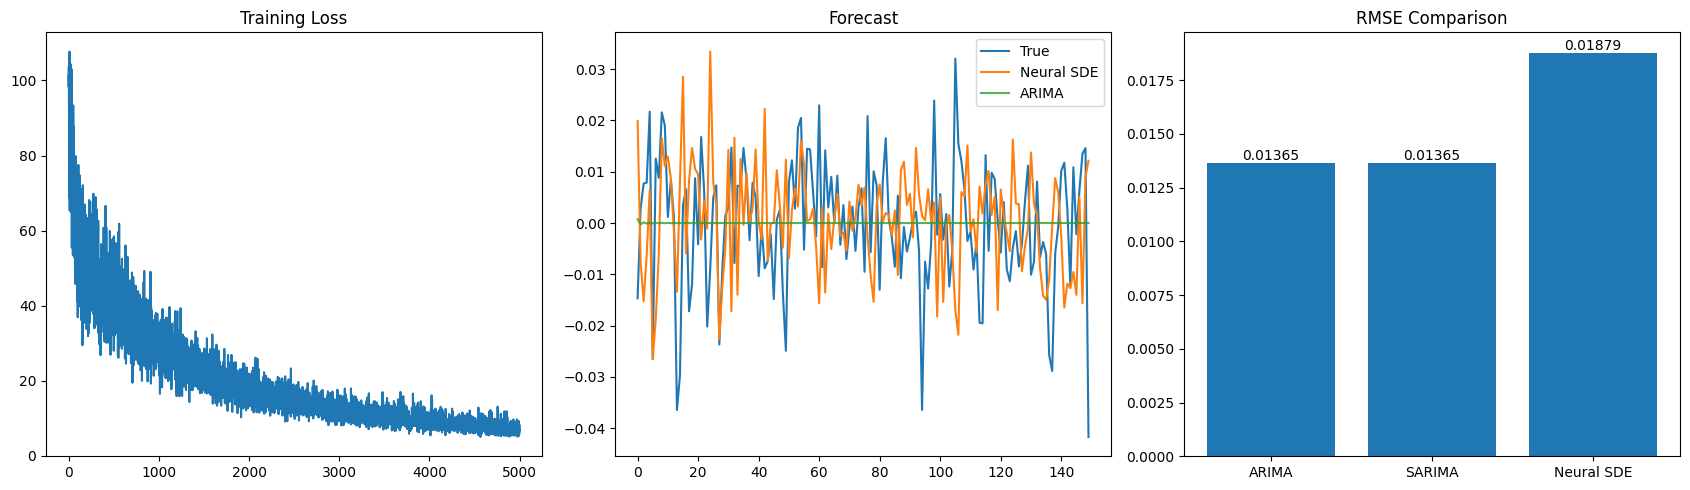

In [66]:
plot_n = 150

fig, axes = plt.subplots(1,3, figsize=(17,5))

# loss
axes[0].plot(losses)
axes[0].set_title("Training Loss")

# predictions
axes[1].plot(Y_test[:plot_n], label="True")
axes[1].plot(nsde_pred[:plot_n], label="Neural SDE")
axes[1].plot(arima_pred[:plot_n], label="ARIMA", alpha=0.8)
axes[1].legend()
axes[1].set_title("Forecast")

# rmse
models = ["ARIMA","SARIMA","Neural SDE"]
vals = [arima_rmse, sarima_rmse, nsde_rmse]

bars = axes[2].bar(models, vals)

for b,v in zip(bars,vals):
    axes[2].text(b.get_x()+b.get_width()/2, v, f"{v:.5f}",
                 ha="center", va="bottom")

axes[2].set_title("RMSE Comparison")

plt.tight_layout()
plt.show()

In [67]:
elec = fetch_ucirepo(id=235)
df_raw = elec.data.features.copy()

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [68]:
df_raw["datetime"] = pd.to_datetime(df_raw["Date"] + " " + df_raw["Time"], format="%d/%m/%Y %H:%M:%S")

df_raw = df_raw.dropna(subset=["Global_active_power"])
df_raw["Global_active_power"] = pd.to_numeric(
    df_raw["Global_active_power"], errors="coerce"
)
df_raw = df_raw.dropna(subset=["Global_active_power"])
df_raw = df_raw.sort_values("datetime").reset_index(drop=True)

daily = df_raw.set_index("datetime")["Global_active_power"].resample("D").sum()
daily = daily[daily > 10]

series = daily.values.astype(np.float32)
n_days = len(series)

In [69]:
WINDOW_E = 14

log_series = np.log1p(series)

contexts_e = []
targets_e = []

for i in range(len(log_series) - WINDOW_E - 1):
    past = log_series[i : i + WINDOW_E]

    day_idx = i + WINDOW_E
    dow = day_idx % 7
    month = (day_idx // 30) % 12

    dow_sin = np.sin(2 * np.pi * dow / 7)
    dow_cos = np.cos(2 * np.pi * dow / 7)
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    roll_mean = past.mean()
    roll_std = past.std() + 1e-6

    extra = np.array([dow_sin, dow_cos, month_sin, month_cos, roll_mean, roll_std], dtype=np.float32)

    contexts_e.append(np.concatenate([past, extra]).astype(np.float32))
    targets_e.append(log_series[i + WINDOW_E])

X_e = np.array(contexts_e)
Y_e = np.array(targets_e)

INPUT_DIM_E = X_e.shape[1]

In [70]:
TRAIN_RATIO_E = 0.8
n_train_e = int(len(X_e) * TRAIN_RATIO_E)

X_train_e = X_e[:n_train_e]
X_test_e = X_e[n_train_e:]
Y_train_e = Y_e[:n_train_e]
Y_test_e = Y_e[n_train_e:]

xsc_e = StandardScaler()
ysc_e = StandardScaler()

X_train_e = xsc_e.fit_transform(X_train_e)
X_test_e = xsc_e.transform(X_test_e)

Y_train_e_s = ysc_e.fit_transform(Y_train_e.reshape(-1, 1)).flatten()

In [71]:
# SARIMA
sarima_fit = SARIMAX(
    Y_train_e,
    order=(2,0,2),
    seasonal_order=(1,0,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_pred_e = np.asarray(sarima_fit.forecast(len(Y_test_e)))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [72]:
class EnergyDrift(nn.Module):
    def __init__(self, ctx_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1 + ctx_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden // 2),
            nn.SiLU(),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x, ctx):
        return self.net(torch.cat([x, ctx], dim=-1))

energy_net = EnergyDrift(INPUT_DIM_E).to(DEVICE)
print(f"Параметров: {sum(p.numel() for p in energy_net.parameters()):,}")

Параметров: 27,649


In [73]:
def simulate_energy(net, ctx, n_steps=N_STEPS, dt=DT):
    B = ctx.shape[0]
    X = torch.zeros(B, 1, device=DEVICE)
    kl = torch.zeros(B, device=DEVICE)
    sqrt_dt = dt ** 0.5

    for _ in range(n_steps):
        drift = net(X, ctx)
        kl += 0.5 * (drift ** 2).squeeze(-1) * dt
        X = X + drift * dt + sqrt_dt * torch.randn_like(X)

    return X, kl

In [74]:
OBS_STD_E = 0.05

def compute_elbo_energy(net, ctx, y, beta=0.01):
    X_T, kl = simulate_energy(net, ctx)
    log_like = -0.5 / OBS_STD_E ** 2 * ((X_T.squeeze(-1) - y) ** 2)
    elbo = (log_like - beta * kl).mean()
    return -elbo

In [75]:
BATCH_E = 128
N_ITER_E = 4000
LR_E = 3e-4

optimizer_e = torch.optim.Adam(energy_net.parameters(), lr=LR_E)
scheduler_e = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_e, T_max=N_ITER_E, eta_min=1e-5
)

losses_e = []

for it in tqdm(range(1, N_ITER_E + 1)):
    beta_kl = min(0.05, max(0.0, (it - 500) / 1000 * 0.05))

    idx = np.random.randint(0, len(X_train_e), BATCH_E)
    ctx_b = torch.tensor(X_train_e[idx], device=DEVICE)
    y_b = torch.tensor(Y_train_e_s[idx], device=DEVICE)

    optimizer_e.zero_grad()
    loss = compute_elbo_energy(energy_net, ctx_b, y_b, beta=beta_kl)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(energy_net.parameters(), 5.0)
    optimizer_e.step()
    scheduler_e.step()
    losses_e.append(loss.item())

100%|██████████| 4000/4000 [05:12<00:00, 12.80it/s]


In [76]:
M_PRED = 64

energy_net.eval()

with torch.no_grad():
    ctx_test = torch.tensor(X_test_e, device=DEVICE)

    preds_scaled = []
    for _ in range(M_PRED):
        X_T, _ = simulate_energy(energy_net, ctx_test)
        preds_scaled.append(X_T.squeeze(-1).cpu().numpy())

pred_mean_s = np.stack(preds_scaled).mean(axis=0)
pred_std_s = np.stack(preds_scaled).std(axis=0)

pred_log = ysc_e.inverse_transform(pred_mean_s.reshape(-1, 1)).flatten()
pred_log_lo = ysc_e.inverse_transform((pred_mean_s - pred_std_s).reshape(-1, 1)).flatten()
pred_log_hi = ysc_e.inverse_transform((pred_mean_s + pred_std_s).reshape(-1, 1)).flatten()

nsde_pred_e = np.expm1(pred_log)
ci_lo = np.expm1(pred_log_lo)
ci_hi = np.expm1(pred_log_hi)

In [77]:
Y_test_orig = np.expm1(Y_test_e)

def rmse_e(a, b): return np.sqrt(np.mean((a - b) ** 2))
def mae_e(a, b): return np.mean(np.abs(a - b))
def mape_e(a, b): return np.mean(np.abs((a - b) / (np.abs(a) + 1e-8))) * 100

metrics_e = {
    "Neural SDE": nsde_pred_e,
    "SARIMA": np.expm1(sarima_pred_e)
}

print(f"{'Модель':<14} {'RMSE':>10} {'MAE':>10} {'MAPE%':>10}")
for name, pred in metrics_e.items():
    n = min(len(pred), len(Y_test_orig))
    print(f"{name:<14} {rmse_e(Y_test_orig[:n], pred[:n]):>10.2f}"
          f" {mae_e(Y_test_orig[:n], pred[:n]):>10.2f}"
          f" {mape_e(Y_test_orig[:n], pred[:n]):>10.2f}")

Модель               RMSE        MAE      MAPE%
Neural SDE         390.60     279.41      30.12
SARIMA             824.01     710.30      85.88


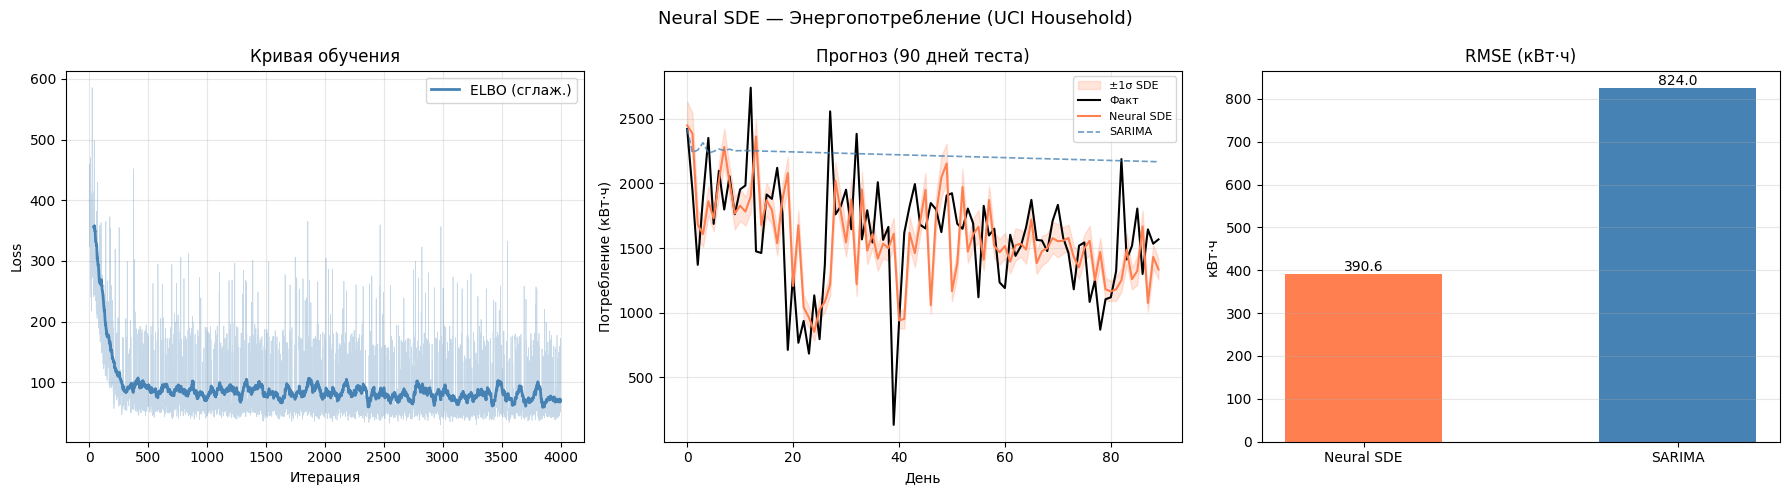

In [78]:
PLOT_N = 90

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Neural SDE — Энергопотребление (UCI Household)", fontsize=13)

# Loss
w = 40
axes[0].plot(losses_e, color="steelblue", lw=0.5, alpha=0.3)
if len(losses_e) > w:
    sm = np.convolve(losses_e, np.ones(w) / w, mode="valid")
    axes[0].plot(range(w - 1, len(losses_e)), sm, color="steelblue", lw=2, label="ELBO (сглаж.)")
axes[0].set_title("Кривая обучения")
axes[0].set_xlabel("Итерация")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Прогноз + доверительный интервал
days = np.arange(PLOT_N)
axes[1].fill_between(days, ci_lo[:PLOT_N], ci_hi[:PLOT_N], alpha=0.2, color="coral", label="±1σ SDE")
axes[1].plot(days, Y_test_orig[:PLOT_N], color="black", lw=1.5, label="Факт")
axes[1].plot(days, nsde_pred_e[:PLOT_N], color="coral", lw=1.5, label="Neural SDE")
axes[1].plot(days, np.expm1(sarima_pred_e[:PLOT_N]), color="steelblue", lw=1.2, alpha=0.8, linestyle="--", label="SARIMA")
axes[1].set_title("Прогноз (90 дней теста)")
axes[1].set_xlabel("День")
axes[1].set_ylabel("Потребление (кВт·ч)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# RMSE bar chart
names = list(metrics_e.keys())
vals = [rmse_e(Y_test_orig[:min(len(p), len(Y_test_orig))],
               p[:min(len(p), len(Y_test_orig))])
        for p in metrics_e.values()]

bars = axes[2].bar(names, vals, color=["coral", "steelblue", "gray"], width=0.5)
for b, v in zip(bars, vals):
    axes[2].text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}",
                 ha="center", va="bottom", fontsize=10)
axes[2].set_title("RMSE (кВт·ч)")
axes[2].set_ylabel("кВт·ч")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()